In [1]:
from probjax.distributions import *
from probjax.distributions.transformed_distribution import TransformedDistribution
import jax
import jax.numpy as jnp
from probjax.core.custom_primitives.random_variable import rv

from jax.api_util import flatten_fun_nokwargs


import matplotlib.pyplot as plt
key = jax.random.PRNGKey(0)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Distributions

Just testing some of the distributions

## Continous Distributions

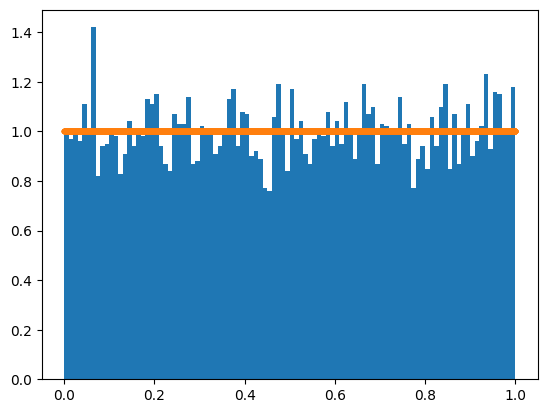

In [2]:
p = Uniform(low=0., high=1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


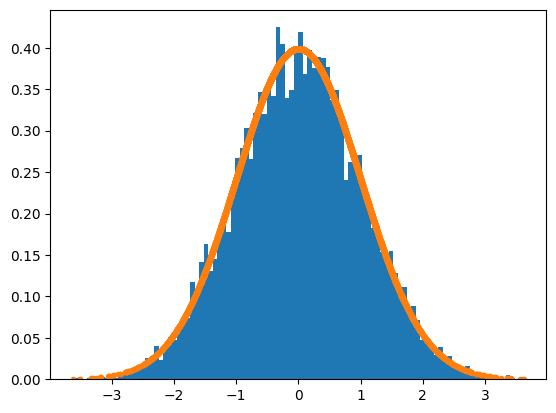

In [3]:
p = Normal(0.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


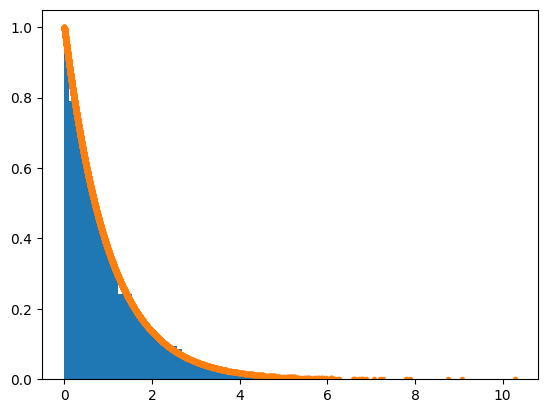

In [4]:
p = Gamma(1.,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


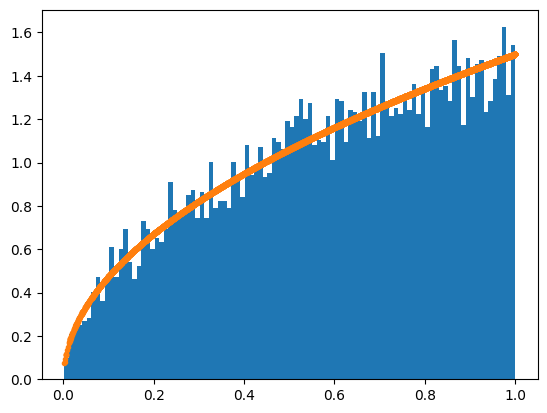

In [5]:
p = Beta(1.5,1.)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


Array(True, dtype=bool)

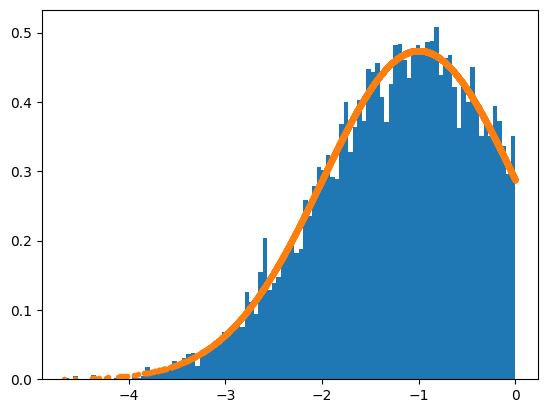

In [6]:
p = TruncatedNormal(-1.,1., low=-100., high=1.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
jnp.isfinite(log_prob).all()

In [7]:
jax.tree_util.tree_flatten(p)

([Array(-1., dtype=float32, weak_type=True),
  Array(1., dtype=float32, weak_type=True),
  Array(-100., dtype=float32, weak_type=True),
  Array(1., dtype=float32, weak_type=True)],
 PyTreeDef(CustomNode(TruncatedNormal[None], [*, *, *, *])))

In [8]:
samples[~jnp.isfinite(samples)].shape

(0,)

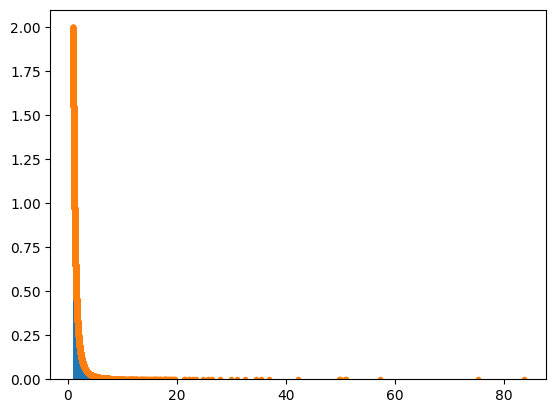

In [9]:
p = Pareto(2.,1.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

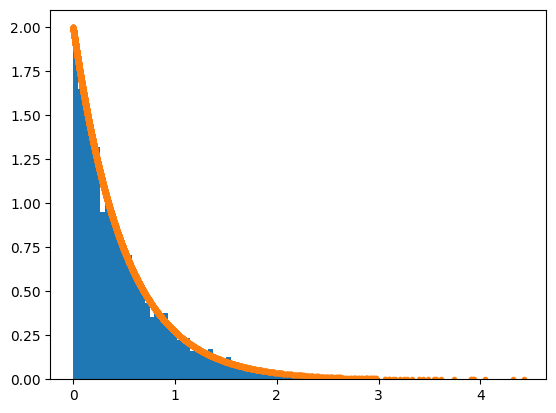

In [10]:
p = Exp(2.)
samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")

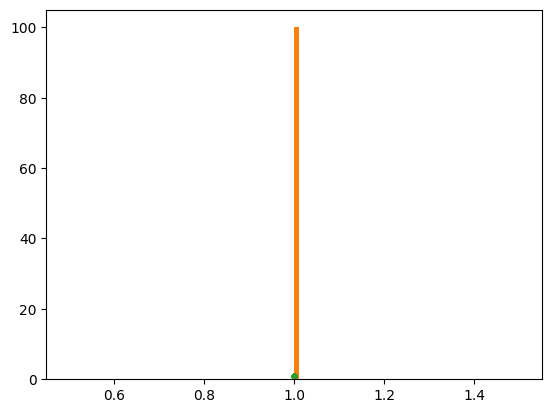

In [11]:
p = Dirichlet(jnp.array([1.]))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")



In [12]:
flatt_p, tree_p = jax.tree_util.tree_flatten(p)
q = jax.tree_util.tree_unflatten(tree_p, flatt_p)

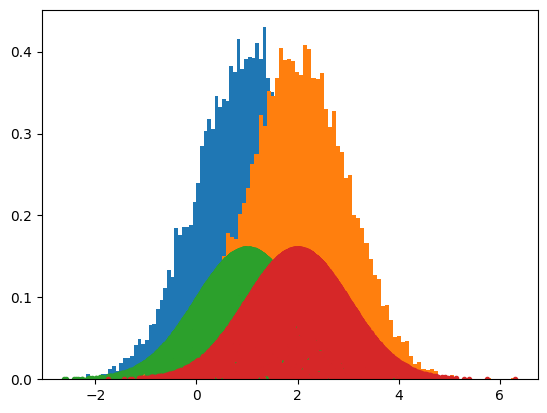

In [13]:
p = MultivariateNormal(jnp.array([1.,2.]), jnp.eye(2))
samples = p.sample(key, (10000,))

_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)

log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")


## Discrete

(0.0, 1.0)

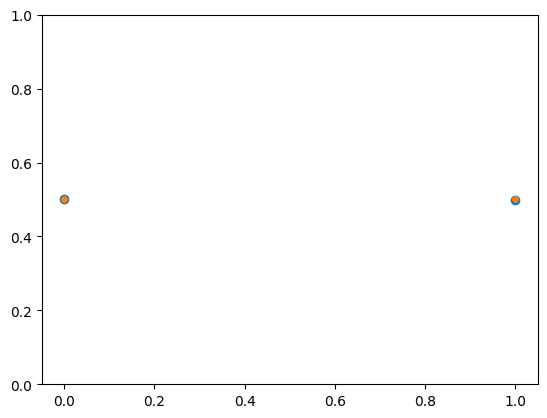

In [14]:
p = Bernoulli(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

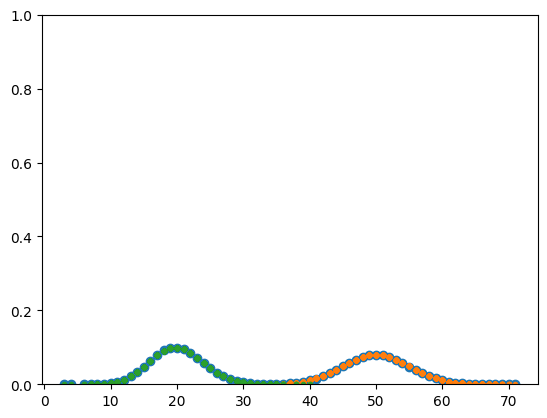

In [15]:
p = Binomial(jnp.array([100, 100]), jnp.array([0.5, 0.2]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

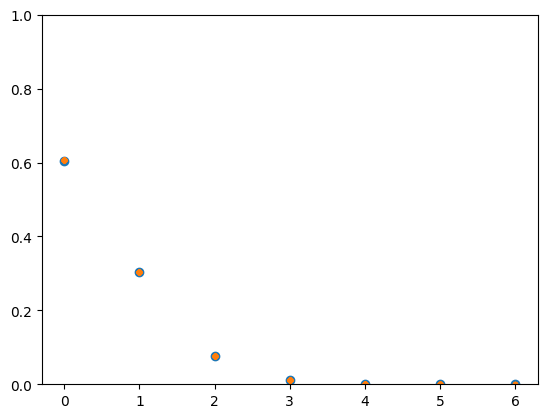

In [16]:
p = Poisson(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

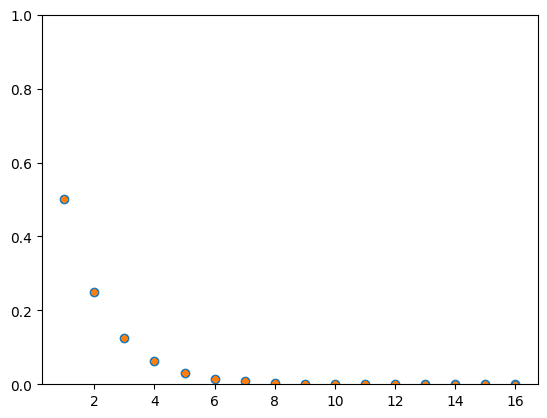

In [17]:
p = Geometric(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

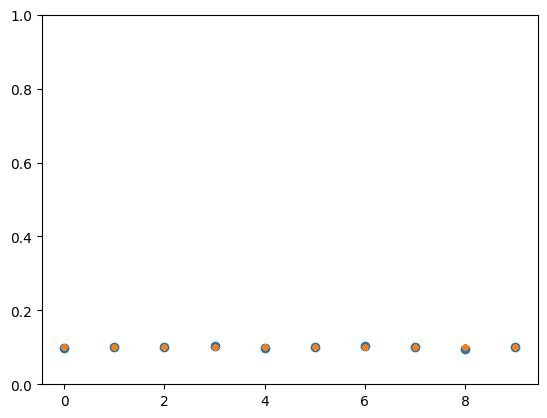

In [18]:
p = Categorical(jnp.ones((10)))
samples = p.sample(key, (10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

In [19]:
flatten, tree =jax.tree_util.tree_flatten(p)

jax.tree_util.tree_unflatten(tree, flatten).sample(key, (10000,))

Array([3, 1, 6, ..., 2, 0, 8], dtype=int32)

In [20]:
flatten

[Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32)]

(0.0, 1.0)

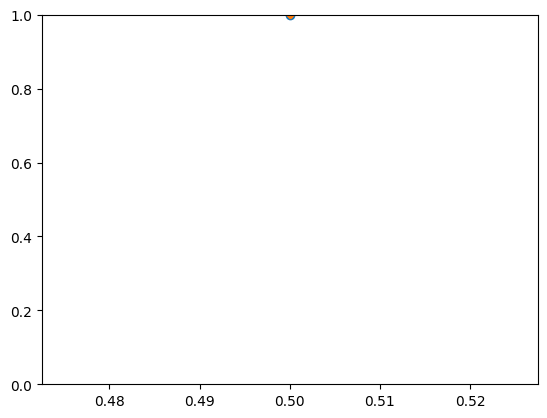

In [21]:
p = Dirac(jnp.array([0.5]))
samples = p.sample(key, (100000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/100000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

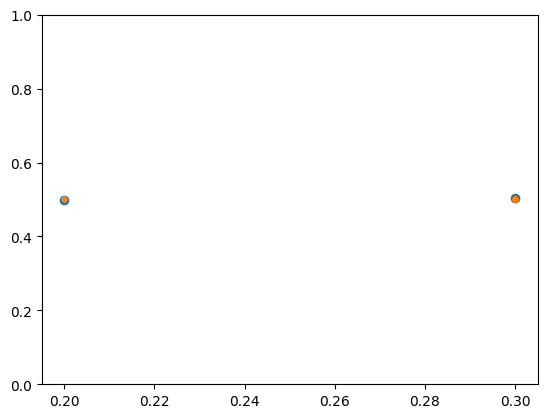

In [22]:
p = Empirical(jnp.array([0.2, 0.3]))
samples = p.sample(key, (10000,))
support, counts = jnp.unique(samples, return_counts=True)
_ = plt.plot(support, counts/10000, "o")
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".", color="C1")
plt.ylim(0,1)

# Independent

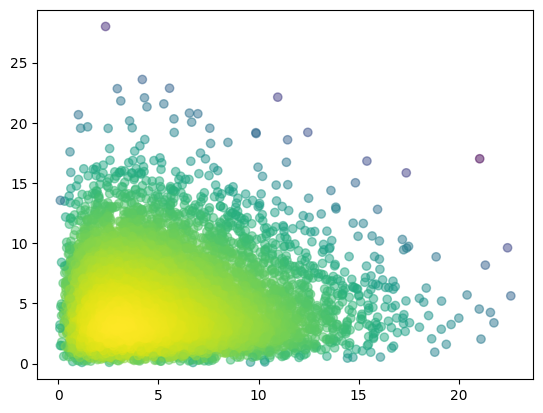

In [23]:
p1 = Chi2(5, jnp.zeros((2,)), jnp.ones((2,)))

p = Independent(p1, 1)

samples = p.sample(key, (10000,))
log_prob = p.log_prob(samples)

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

() (2,)
(10000,)


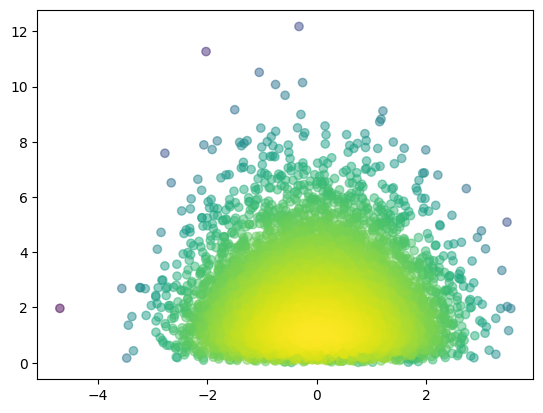

In [24]:
p1 = Normal(jnp.zeros((1,)), jnp.ones((1,)))
p2 = Gamma(jnp.ones((1,))*2, jnp.ones((1,)))

p = Independent([p1, p2], 1)
print(p1.event_shape, p.event_shape)

samples = p.sample(key, (10000,))
log_prob = p.log_prob(samples)

print(log_prob.shape)

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=log_prob)

# Mixture

() (2,)
(10000, 2)
(10000,)


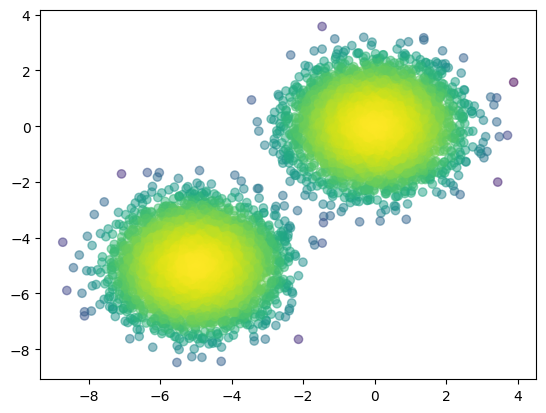

In [25]:
p1 = MultivariateNormal(jnp.array([0.,0.]),jnp.eye(2))
p2 = MultivariateNormal(jnp.array([-5., -5]),jnp.eye(2))
p = Mixture(jnp.array([0.5,0.5]), [p1,p2])
print(p.batch_shape, p.event_shape)
samples = p.sample(key, (10000,))
print(samples.shape)
#_ = plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
print(log_prob.shape) 
#plt.plot(samples, jnp.exp(log_prob), ".")

plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c= log_prob)


() ()
(10000,)
(10000,)


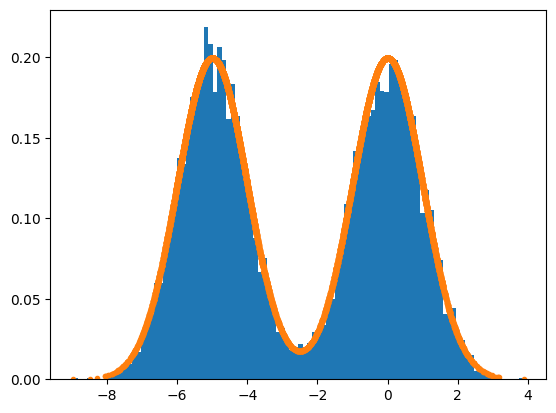

In [26]:
p1 = Normal(jnp.array([0.]),jnp.array([1.]))
p2 = Normal(jnp.array([-5.]),jnp.array([1.]))

p = Normal(jnp.array([0., -5.]),jnp.array([1., 1.]))

#p = Mixture(jnp.array([0.5,0.5]), p)
p = Mixture(jnp.array([0.5,0.5]), [p1,p2])
print(p.batch_shape, p.event_shape)
samples = p.sample(key, (10000,))
print(samples.shape)
_ = plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
print(log_prob.shape) 
plt.plot(samples, jnp.exp(log_prob), ".")

# SDEs

In [27]:
from probjax.distributions.sde import *

In [28]:
# A = jnp.array([[0.,1.],[-1.,0.]])
# B = jnp.eye(2)*0.1

# ts = jnp.linspace(0., 5., 1000)
# p0 = Independent(Normal(jnp.zeros((2,)), jnp.ones((2,))), 1)
# sde = LinearTimeInvariantSDE(A, B,p0 )

# xs = sde.sample(key, ts,(5,))
# mean = sde.mean(ts)
# std = sde.stddev(ts)
# _ = plt.plot(ts,xs[:, :, 0].T, "C0")
# _ = plt.plot(ts, xs[..., 1].T, "C1")
# _ = plt.plot(ts, mean[..., 0], "C0--")
# _ = plt.plot(ts, mean[..., 1], "C1--")


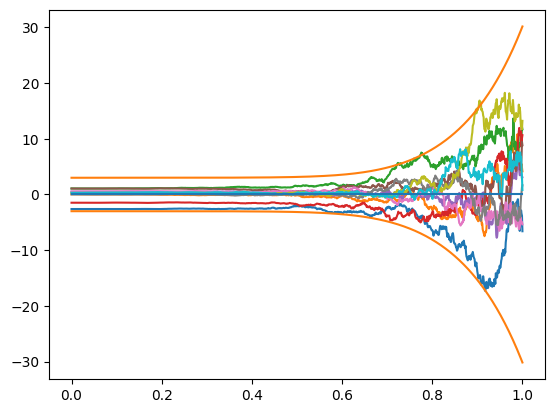

In [29]:
p0 = Normal(jnp.zeros(1), jnp.ones(1))
ts = jnp.linspace(0., 1., 1000)
sde = VESDE(p0)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(10,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

In [35]:
def is_sorted_along_axis(arr, axis=-1):
    return jnp.all(jnp.diff(arr, axis=axis) >= 0)


class VPSDE(LinearTimeVariantSDE):

    def __init__(
        self, p0: Distribution, beta_max: float = 10.0, beta_min: float = 0.1
    ) -> None:
        self.beta_max = beta_max
        self.beta_min = beta_min

        
        drift_matrix = lambda t: jnp.atleast_1d((
            -0.5 * (beta_min + t * (beta_max - beta_min))
        ))
        diffusion_matrix = lambda t: jnp.atleast_1d(jnp.sqrt(
            beta_min + t * (beta_max - beta_min)
        ))

        super().__init__(drift_matrix, diffusion_matrix, p0)

    def mean(self, ts: Array, x0=None, **kwargs) -> Array:
        if x0 is None:
            mu0 = self.p0.mean
        else:
            mu0 = x0

        phi = jnp.exp(
            -0.25 * ts**2 * (self.beta_max - self.beta_min) - 0.5 * ts * self.beta_min
        )

        phi = phi[..., None]
        mu = phi * mu0
        return mu

    def variance(self, ts: Array, x0=None, **kwargs) -> Array:
        if x0 is None:
            var0 = self.p0.variance
        else:
            var0 = jnp.zeros(x0.shape)
        phi = jnp.exp(
            -0.5 * ts**2 * (self.beta_max - self.beta_min) - ts * self.beta_min
        )
        phi = phi[..., None]
        var = 1 + phi * (var0 - 1)
        return var
    

    def log_prob(self, x: Array, t: Array, x0=None) -> Array:
        mu = self.mean(t, x0=x0)
        std = self.stddev(t, x0=x0)

        return jax.scipy.stats.norm.logpdf(x, mu, std)


In [36]:
p0 = Normal(jnp.zeros((10,)), jnp.ones(10,))
sde = VPSDE(p0)
ts = jax.random.uniform(key, (10,)) 

def samples(ts):
    mean_start = sde.mean(ts[...,0])
    std_start = sde.stddev(ts[...,0])

    x0 = jax.random.normal(key, mean_start.shape) * std_start + mean_start
    ts_diff = jnp.diff(ts,axis=-1)
    dWt = jax.random.normal(key, ts_diff.shape) * jnp.sqrt(ts_diff)
    Wt = jnp.cumsum(dWt, axis=-1)

    phi = jnp.exp(sde.drift()

    
    return noise


samples(jnp.ones((10,1)))

Array([], dtype=float32)

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

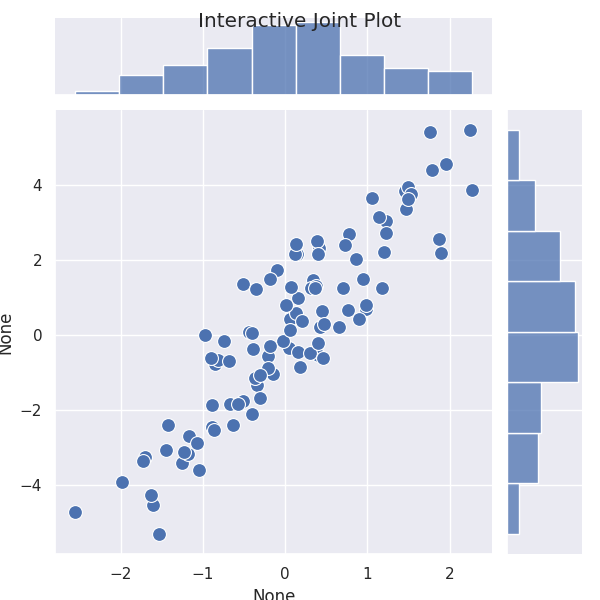

AttributeError: 'PairGrid' object has no attribute 'ax_joint'

In [33]:
%matplotlib widget


# Generate sample data
np.random.seed(0)
x = np.random.normal(size=100)
y = 2 * x + np.random.normal(size=100)

new_xs = []
new_ys = []

# Create a jointplot
g = sns.jointplot(x=x, y=y, kind="scatter", s=100)
g.fig.suptitle("Interactive Joint Plot")

# Create variables to hold the marginal histogram axes
ax_marg_x = g.ax_marg_x
ax_marg_y = g.ax_marg_y

# Add interactivity to the jointplot
def onclick(event):
    if event.inaxes == g.ax_joint:
        x_data, y_data = g.ax_joint.transData.inverted().transform((event.x, event.y))
        new_xs.append(x_data)
        new_ys.append(y_data)
        plt.scatter(x_data, y_data, c='r', s=100)

        # Update the marginal histograms using sns.histplot
        ax_marg_x.cla()
        ax_marg_y.cla()

        g.plot_marginals(sns.histplot, kde=False, color='b')
        sns.histplot(x=new_xs, ax=ax_marg_x, color='r' ,kde=False)
        sns.histplot(y=new_ys, ax=ax_marg_y, color='r', orientation="horizontal", kde=False)

        g.ax_joint.figure.canvas.draw()

g.fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

In [30]:
import arviz as az
import numpy as np

az.rcParams["plot.backend"] = "bokeh"
az.output_notebook()

x = np.random.normal(size=1000) + 2
y = np.random.normal(size=1000)
z = np.random.normal(size=1000) + x
data = dict(x=x, y=y, z =z)

fig = az.plot_pair(
    data,
    kind = "scatter",
    marginals=True,
    scatter_kwargs={"size": 1, "color": "C0"},
    kde_kwargs={"color": "C0"},
    figsize=(11.5, 5),
)


Loading BokehJS ...

In [29]:

az.output_notebook()
fig = az.plot_density( x)
fig

Loading BokehJS ...

array([[figure(id='p5713', ...)]], dtype=object)

In [18]:
fig[1][0]

figure(id='p3811', ...)

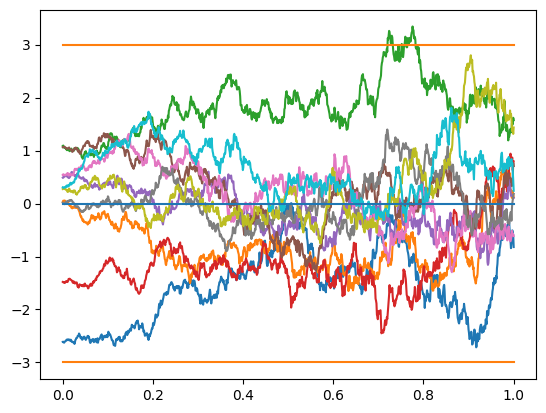

In [37]:
p0 = Normal(jnp.zeros(1), jnp.ones(1))
ts = jnp.linspace(0., 1., 1000)
sde = VPSDE(p0)
mean = sde.mean(ts)
variance = sde.variance(ts)

xs = sde.sample(key, ts,(10,))
_ = plt.plot(ts, jnp.squeeze(xs).T)
_ = plt.plot(ts, mean)
_ = plt.plot(ts, mean + 3*jnp.sqrt(variance), color="C1")
_ = plt.plot(ts, mean - 3*jnp.sqrt(variance), color="C1")

# Transformed Distributon

(0.0, 1.0)

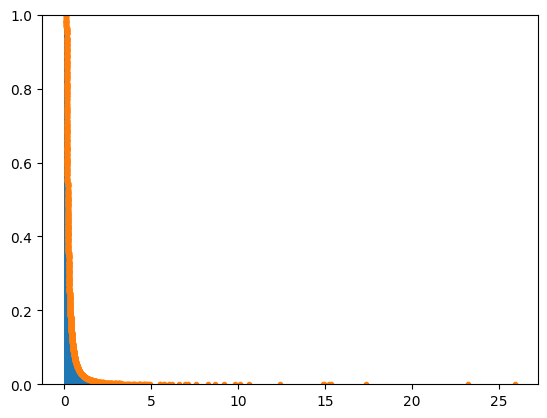

In [ ]:
p0 = Normal(0.,1.)
p = TransformedDistribution(p0, lambda x: jnp.exp(x -2)**2)

samples = p.sample(key, (10000,))
plt.hist(samples, bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".")
plt.ylim(0,1)

(0.0, 1.0)

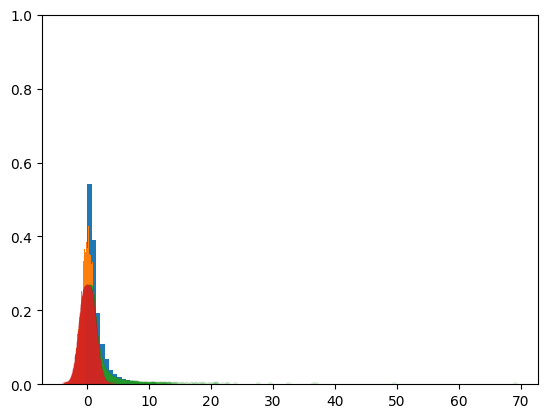

In [ ]:
p0 = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)

def t(x):
    x = x.at[...,0].set(jnp.exp(x[...,0]))
    return x

p = TransformedDistribution(p0, t)

samples = p.sample(key, (10000,))
_ = plt.hist(samples[:,0], bins=100, density = True)
_ = plt.hist(samples[:,1], bins=100, density = True)
log_prob = p.log_prob(samples)
plt.plot(samples, jnp.exp(log_prob), ".", alpha=0.1)
plt.ylim(0,1)

## Divergences

### KL divergence

In [ ]:
from probjax.distributions.divergences import kl_divergence

p0 = Normal(0.,1.)
p1 = Normal(0.,2.)
dist = kl_divergence(p0,p1)

dist

Array(0.318, dtype=float32, weak_type=True)